In [1]:
import pandas as pd

In [2]:
data_path = "../1_data_collection/all_data.csv"
all_data_df = pd.read_csv(data_path)


In [ ]:
#make sure to installed it correctly
!pip show vaderSentiment


Name: vaderSentiment
Version: 3.3.2
Summary: VADER Sentiment Analysis. VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media, and works well on texts from other domains.
Home-page: https://github.com/cjhutto/vaderSentiment
Author: C.J. Hutto
Author-email: cjhutto@gatech.edu
License: MIT License
Location: /home/ubuntu/group_project/ml_test_env/lib/python3.8/site-packages
Requires: requests
Required-by: 


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sentiment_analyzer = SentimentIntensityAnalyzer()


def get_compound_score(text):
    if isinstance(text, str):
        return sentiment_analyzer.polarity_scores(text)["compound"]
    else:
        return None  # if nan or no str

all_data_df["sentiment_score"] = all_data_df["text"].apply(get_compound_score)


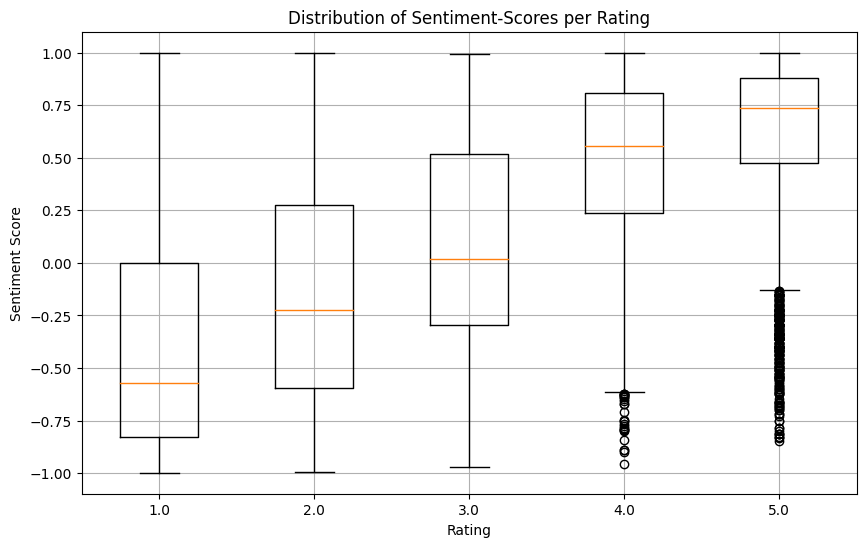

In [17]:
import matplotlib.pyplot as plt
import numpy as np

ratings = sorted(all_data_df["rating_x"].dropna().unique())
grouped_scores = [all_data_df[all_data_df["rating_x"] == r]["sentiment_score"].dropna() for r in ratings]

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_scores, labels=ratings)
plt.title("Distribution of Sentiment-Scores per Rating")
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.grid(True)
plt.show()


In [ ]:
"""
we see clear correlating structure of ratings and sentiment scores however they are not identical which was expected
and which can be good since ratings do not always mirror their text descriptions 
"""

In [ ]:
## lets try a second external sentiment 

from textblob import TextBlob

def get_textblob_sentiment(text):
    if isinstance(text, str):
        return TextBlob(text).sentiment.polarity
    else:
        return None

all_data_df["textblob_score"] = all_data_df["text"].apply(get_textblob_sentiment)


In [22]:
all_data_df.head(1)

,name,country,rating_x,title,text,date_of_experience,has_reply,company_x,company_y,website,rating_y,number_review,domain,5_star_percentage,4_star_percentage,3_star_percentage,2_star_percentage,1_star_percentage,sentiment_score,textblob_score
0,Przemysław Rosuł,PL,1.0,Ignoring the specified pickup time,Ignoring the specified pickup time. Providing ...,2025-05-13,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,-0.7013,0.0


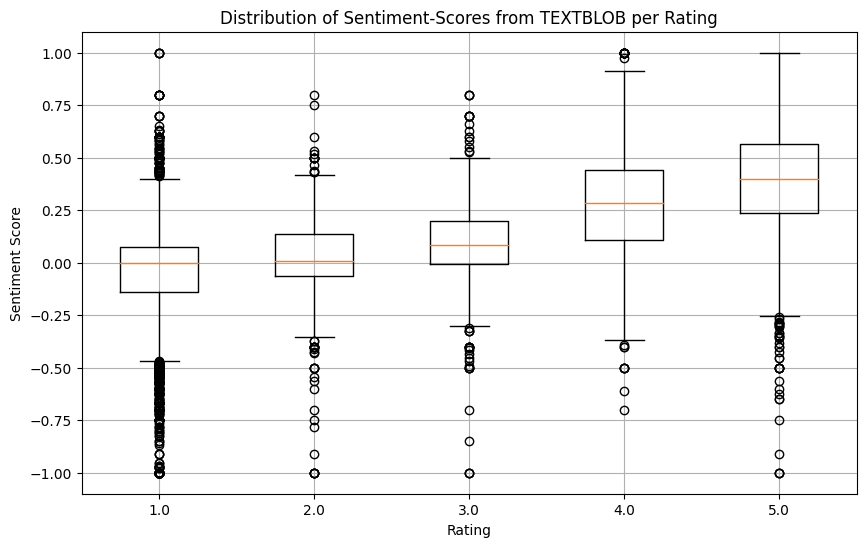

In [20]:

ratings = sorted(all_data_df["rating_x"].dropna().unique())
grouped_scores = [all_data_df[all_data_df["rating_x"] == r]["textblob_score"].dropna() for r in ratings]

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_scores, labels=ratings)
plt.title("Distribution of Sentiment-Scores from TEXTBLOB per Rating")
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.grid(True)
plt.show()


In [ ]:
"""
it is safe to say that sensitvity scores from textblob diverge more than those from vader library
however in this case we see huge disparities especially in lower class ratings which lead to 
questionning the quality from textblob in our use case
"""

'\nit is safe to say that sensitvity scores from textblob diverge more than those from vader library\nhowever in this case we see huge disparities which lead to questionning the quality from textblob\nfor our use case\n'

In [ ]:
from afinn import Afinn

afinn = Afinn()

def get_afinn_score(text):
    if isinstance(text, str):
        return afinn.score(text)
    else:
        return None

all_data_df["afinn_score"] = all_data_df["text"].apply(get_afinn_score)

In [25]:
all_data_df.head(1)

,name,country,rating_x,title,text,date_of_experience,has_reply,company_x,company_y,website,...,number_review,domain,5_star_percentage,4_star_percentage,3_star_percentage,2_star_percentage,1_star_percentage,sentiment_score,textblob_score,afinn_score
0,Przemysław Rosuł,PL,1.0,Ignoring the specified pickup time,Ignoring the specified pickup time. Providing ...,2025-05-13,0.0,www.viator.com,Viator.com,www.viator.com,...,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,-0.7013,0.0,0.0


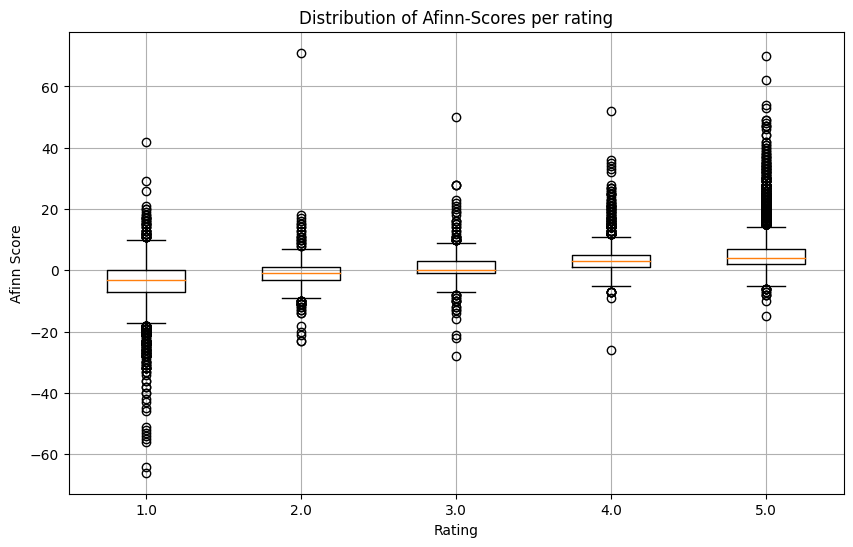

In [27]:
ratings = sorted(all_data_df["rating_x"].dropna().unique())
grouped_afinn = [all_data_df[all_data_df["rating_x"] == r]["afinn_score"].dropna() for r in ratings]

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_afinn, labels=ratings)
plt.title("Distribution of Afinn-Scores per rating")
plt.xlabel("Rating")
plt.ylabel("Afinn Score")
plt.grid(True)
plt.show()